# Übung 10

**Gruppenname:**

*WMJD*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

... werden wir intensiv mit einem Datensatz arbeiten und uns mit ihm vertraut machen.

### 10.1 Datenaufbereitung (Corona Pandemie)

In dieser Übungsaufgabe wird es darum gehen, weitere Praxiserfahrung bei der Datenaufbereitung zu sammeln. Wie Sie im Rahmen der Veranstaltung gelernt haben, lässt sich Datenaufbereitung nur schwer auf Vorlesungsfolien vermitteln, sondern muss praktisch geübt werden. Sie werden Daten der Corona-Pandemie analysieren. Die Daten stammen vom Robert Koch Institut.

- Ziel dieser Übung ist es, den Datensatz des Robert Koch Instituts so aufzubereiten, dass Sie am Ende einen Pandas DataFrame vorliegen haben, der die Anzahl Neuinfizierter pro Tag und Bundesland enthält.

**Ihre Aufgaben**


(1) Da der Datensatz des Robert Koch Instituts mittlerweile leider nicht mehr online verfügbar ist, haben wir Ihnen [hier](https://data.bialonski.de/ds/RKI_COVID-19.zip) einen Export der Daten (aus dem März 2022) hinterlegt.

- Die heruntergeladene Datei ist mehrere hundert Megabytes groß. Um Plattenplatz zu sparen, ist es empfehlenswert, die Datei in ihrem gezippten Format zu belassen. Die Pandas-Bibliothek, mit der wir die Daten später untersuchen werden, kann [gezippte Dateien direkt importieren](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html).


(2) Importieren Sie die Daten in einen Pandas DataFrame, den Sie `df_germany` nennen.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

df_germany = pd.read_csv("./data/RKI_COVID-19.zip")

(3) Untersuchen Sie den importierten DataFrame:

- Welche Spalten weist der DataFrame auf?
- Welche Information enthält eine Zeile des DataFrames?
- In welcher Spalte ist die Information über die Anzahl der Neuinfizierten enthalten?

In [2]:
df_germany.head()

,IdBundesland,Bundesland,IdLandkreis,Landkreis,Altersgruppe,Altersgruppe2,Geschlecht,Meldedatum,Refdatum,IstErkrankungsbeginn,NeuerFall,NeuerTodesfall,NeuGenesen,AnzahlFall,AnzahlTodesfall,AnzahlGenesen,Datenstand,ObjectId
0,1,Schleswig-Holstein,1001,SK Flensburg,A05-A14,Nicht übermittelt,W,2022/01/14 00:00:00+00,2022/01/12 00:00:00+00,1,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",1
1,1,Schleswig-Holstein,1001,SK Flensburg,A00-A04,Nicht übermittelt,M,2020/09/30 00:00:00+00,2020/09/30 00:00:00+00,0,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",2
2,1,Schleswig-Holstein,1001,SK Flensburg,A05-A14,Nicht übermittelt,W,2022/01/14 00:00:00+00,2022/01/13 00:00:00+00,1,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",3
3,1,Schleswig-Holstein,1001,SK Flensburg,A05-A14,Nicht übermittelt,W,2022/01/14 00:00:00+00,2022/01/14 00:00:00+00,0,0,-9,0,2,0,2,"22.03.2022, 00:00 Uhr",4
4,1,Schleswig-Holstein,1001,SK Flensburg,A00-A04,Nicht übermittelt,M,2020/10/29 00:00:00+00,2020/10/29 00:00:00+00,0,0,-9,0,1,0,1,"22.03.2022, 00:00 Uhr",5


Das DataFrame weist die Spalten `IdBundesland`, `Bundesland`, `IdLandkreis`, `Landkreis`, `Altersgruppe`, `Altersgruppe2`, `Geschlecht`, `Meldedatum`, `Refdatum`, `IstErkrankungsbeginn`, `NeuerFall`, `NeuerTodesfall`, `NeuGenesen`, `AnzahlFall`, `AnzahlTodesfall`, `AnzahlGenesen`, `Datenstand` und `ObjectId` auf.
Eine Zeile enthält die Informationen zu einer Personengruppe pro Tag.
Die Spalte `AnzahlFall` gibt an, wie viele Personen infiziert wurden.

(4) Setzen Sie die Spalte `Meldedatum` auf den Typ datetime Index.

In [3]:
df_germany["Meldedatum"] = pd.to_datetime(df_germany["Meldedatum"])

(5) Erstellen Sie aus dem alten DataFrame einen neuen DataFrame `covid`, der folgende Spalten enthält:

- Erste Spalte: `Meldedatum`
- 16 weitere Spalten, die jeweils nach einem Bundesland benannt sind
- letzte Spalte: `Deutschland`

Der DataFrame enthält also die Anzahl der Neuinfizierten pro Tag (Meldedatum) und Bundesland sowie für die gesamte Bundesrepublik (Spalte Deutschland).

- Beachten Sie: Vermutlich werden Sie für die Lösung dieser Teilaufgabe etwas mehr Zeit benötigen und im Internet in der Pandas Dokumentation recherchieren müssen.


In [4]:
covid = df_germany[["Meldedatum", "Bundesland", "AnzahlFall"]].groupby(["Meldedatum", "Bundesland"]).sum()["AnzahlFall"].reset_index().pivot(index="Meldedatum", columns="Bundesland")["AnzahlFall"]
covid["Deutschland"] = covid.T.sum()
covid.reset_index(inplace=True)
covid["Meldedatum"] = pd.to_datetime(covid["Meldedatum"])

(6) Visualisieren Sie die Anzahl der Neuinfizierten in Nordrhein-Westfalen sowie in der gesamten Bundesrepublik als Funktion der Zeit.

- Die x-Achse ist mit "Meldedatum" beschriftet.
- Auf der x-Achse stehen Datumsangaben (z.B: '2020-03-17'), keine bloßen Integers.
- Der Titel der Abbildung lautet "Anzahl Neuinfektionen".

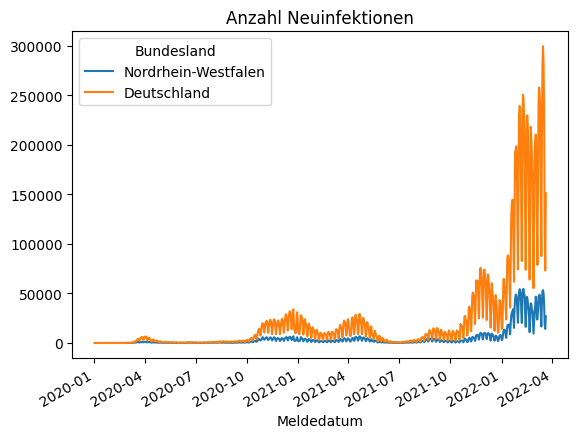

In [5]:
covid.set_index("Meldedatum")[["Nordrhein-Westfalen", "Deutschland"]].plot(title="Anzahl Neuinfektionen")
plt.show()

### 10.2 Exploration (Corona Pandemie)

Sie werden die Daten aus der vorangegangenen Aufgabe in dieser Aufgabe analysieren.

- Diese Aufgabe ist freier gehalten als die vorangegangene Aufgabe.


**Schritte**

(1) Importieren Sie die Daten.

(2) Untersuchen Sie die Daten: **Erzeugen Sie Fragen** an die Daten und notieren Sie sie hier.

- Welches Bundesland hatte insgesamt die meisten Fälle?
- Wie viel Prozent der Gesamtfälle machen die jeweiligen Bundesländer aus?
- Zu welchem Zeitpunkt war die Anzahl der Neuinfektionen am höchsten?
- Hatte Corona einen Einfluss auf die Bestehensquote der IHK Abschlussprüfung der MATSE Ausbildung?

(3) **Untersuchen** Sie Ihre Fragen mit den angegebenen Daten und **visualisieren** Sie bzw. **beschreiben** Sie Ihre Erkenntnisse.

- Hinweis: Ich lade Sie herzlich dazu ein, weitere Datenquellen aus dem Netz zu Ihren Untersuchungen hinzuziehen. Geben Sie in diesem Falle Ihre Datenquellen hier an.


In [6]:
covid.set_index("Meldedatum").sum()

Bundesland
Baden-Württemberg          2747848.0
Bayern                     3592444.0
Berlin                      846932.0
Brandenburg                 636550.0
Bremen                      136938.0
Hamburg                     404375.0
Hessen                     1296522.0
Mecklenburg-Vorpommern      346180.0
Niedersachsen              1447116.0
Nordrhein-Westfalen        3848647.0
Rheinland-Pfalz             770712.0
Saarland                    215655.0
Sachsen                    1183412.0
Sachsen-Anhalt              542572.0
Schleswig-Holstein          439832.0
Thüringen                   537539.0
Deutschland               18993274.0
dtype: float64

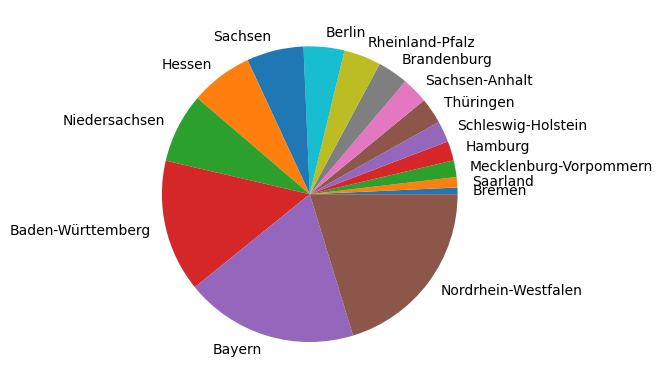

In [7]:
covid.set_index("Meldedatum").sum()[:-1].sort_values().plot(kind="pie")
plt.show()

In [8]:
covid["Meldedatum"][covid["Deutschland"].argmax()]

Timestamp('2022-03-16 00:00:00+0000', tz='UTC')

In [9]:
# https://pes.ihk.de//Berufsauswahl.cfm
ihk_matse = pd.DataFrame({
    "2022-11": [.72, 3, 2, 8, 6, 3, 3],
    "2022-04": [.905, 14, 68, 62, 20, 7, 1],
    "2021-11": [.778, 1, 2, 8, 12, 4, 0],
    "2021-04": [.879, 7, 59, 65, 36, 14, 1],
    "2020-11": [.731, 1, 6, 5, 10, 3, 1],
    "2020-04": [.866, 10, 38, 85, 40, 16, 5],
    "2019-11": [.857, 5, 4, 6, 3, 1, 2],
    "2019-04": [.906, 8, 52, 62, 27, 6, 5],
    "2018-11": [.905, 4, 9, 3, 4, 1, 0],
    "2018-04": [.975, 26, 95, 64, 10, 2, 2],
    "2017-11": [.727, 2, 0, 6, 2, 0, 1],
    "2017-04": [.944, 4, 69, 41, 14, 3, 3]
}).T.reset_index()
ihk_matse.columns = ["date", "quote", 1, 2, 3, 4, 5, 6]
ihk_matse["date"] = pd.to_datetime(ihk_matse["date"])

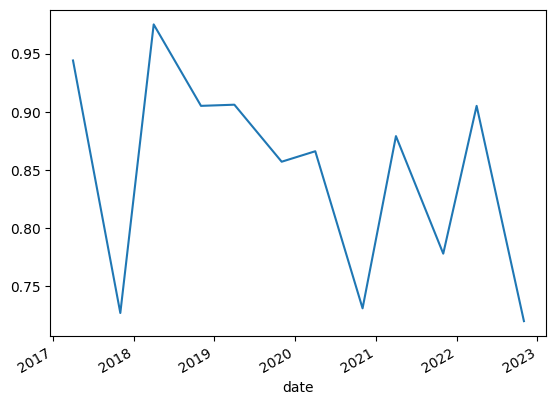

In [10]:
ihk_matse.set_index("date")["quote"].plot()
plt.show()

In [11]:
covid.set_index("Meldedatum", inplace=True)
grouped_covid = covid.groupby(by=[covid.index.year, covid.index.month]).sum().rolling(6).sum()
grouped_covid.index = pd.to_datetime([f"{date[0]}-{date[1]}-1" for date in grouped_covid.index])
grouped_covid.rename_axis("date", inplace=True)
grouped_covid.reset_index(inplace=True)
covid_ihk = ihk_matse.merge(grouped_covid, on="date").sort_index(ascending=False)
covid_ihk.fillna(0, inplace=True)

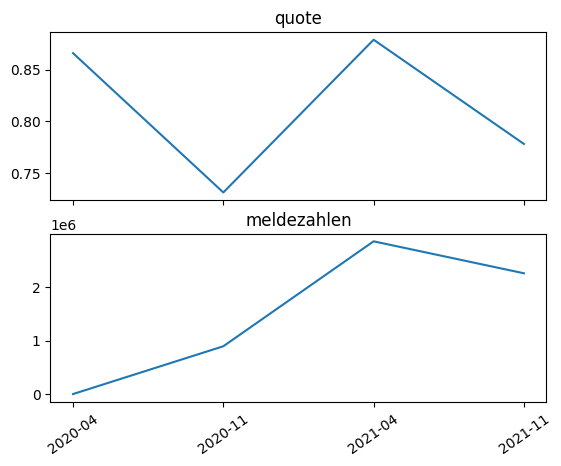

In [12]:
fig, axs = plt.subplots((2), sharex=True)
for ax, value, title in zip(axs, covid_ihk[["date", "quote", "Deutschland"]].set_index("date").T.values, ["quote", "meldezahlen"]):
    ax.set_title(title)
    ax.plot(value)
plt.xticks(range(len(covid_ihk)), [f"{date.year}-{date.month:02}" for date in covid_ihk["date"]], rotation=35)
plt.show()